# Detección de violencia en video de vigilancia
### Pose estimation, ingeniería de movimiento y clasificador GRU

**Contexto breve**
- Objetivo: detectar comportamiento violento en video de vigilancia sin entrenar un clasificador de video desde cero.
- Enfoque: reutilizar un modelo de pose ya entrenado para extraer keypoints por persona, calcular ángulos articulares y su velocidad/aceleración entre frames, suavizar con un filtro de Kalman y clasificar con una red GRU.
- **Este notebook parte de features numéricas sintéticas**, no de video real. Reproducir los pasos de detección de personas y pose (YOLO) y tracking (DeepSORT) requiere GPU y video propio; aquí se documentan esos pasos como referencia y el notebook continúa desde la salida de ese proceso: una tabla de features de movimiento por persona y por segmento de tiempo.
- Artículo completo, con el diagrama interactivo del pipeline: https://fuzzyfrog.ai/es/ai-lab/proyectos/seguridad/deteccion-violencia-video-vigilancia-pose-estimation-gru/


## 0. Pipeline de la solución

- **Fuente**: video de vigilancia + modelo de pose ya entrenado (no se reentrena)
- **Detección + keypoints**: un modelo tipo YOLO-pose detecta personas y sus puntos clave por frame *(referencia, no se ejecuta en este notebook)*
- **Tracking**: se asigna un id consistente por persona a lo largo del video *(referencia, no se ejecuta en este notebook)*
- **Features de movimiento**: ángulos articulares y su velocidad/aceleración entre frames — **punto de partida real de este notebook**
- **Suavizado**: filtro de Kalman sobre la serie de ángulos, validado con un estudio de ablación (con y sin filtro)
- **Clasificación**: red GRU, con hiperparámetros ajustados vía Optuna + validación cruzada
- **Salida**: probabilidad de comportamiento violento por persona y segmento de tiempo

El diagrama interactivo completo está disponible en el artículo enlazado arriba.

```python
# Referencia de cómo se obtendrían los keypoints en Colab (no se ejecuta aquí, requiere GPU y video propio):
#
# !git clone https://github.com/WongKinYiu/yolov7.git
# !wget https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7-w6-pose.pt
# !python deep_sort_tracking_id.py --weights yolov7.pt --img 640 --source mi_video.mp4
```


## 1. Carga de datos

- Dataset sintético: `outputs/features_movimiento_sintetico.csv`
- Cada fila es un segmento de pocos frames para una persona rastreada, con features de movimiento ya calculadas y una etiqueta `Normal` / `Violent`
- Balance de clases cercano a 50/50, similar al del proyecto original tras el muestreo de la clase mayoritaria


In [1]:
import pandas as pd
import numpy as np

dataset = pd.read_csv('outputs/features_movimiento_sintetico.csv')
print(f'El dataset (sintético) tiene {dataset.shape[1]} columnas y {dataset.shape[0]} registros.')
print(dataset['target'].value_counts())
dataset.head(3)


El dataset (sintético) tiene 9 columnas y 2400 registros.
target
Violent    1200
Normal     1200
Name: count, dtype: int64


,video_id,person_id,velocity_mean,acceleration_mean,energy_movimiento,cambios_abruptos,simetria_corporal,radio_expansion,target
0,Violent_0042,3,21.054968,2.689925,32.454177,4,0.263077,27.368008,Violent
1,Normal_0127,1,3.496176,0.826783,10.705259,3,0.061201,27.075202,Normal
2,Normal_0236,2,2.456441,1.661136,9.160077,1,0.041488,37.882839,Normal


## 2. Explicación de los datos

- `velocity_mean` / `acceleration_mean`: velocidad y aceleración promedio de los ángulos articulares en el segmento
- `energy_movimiento`: energía del movimiento (suma de velocidades al cuadrado)
- `cambios_abruptos`: número de cambios bruscos de velocidad dentro del segmento
- `simetria_corporal`: qué tan distinto se mueve el lado izquierdo respecto al derecho
- `radio_expansion`: qué tanto se alejan las extremidades del centro del cuerpo
- `target`: etiqueta de la escena, `Normal` o `Violent`


In [2]:
dataset.groupby('target')[['velocity_mean', 'acceleration_mean', 'energy_movimiento',
                            'cambios_abruptos', 'simetria_corporal']].mean().round(2)


,velocity_mean,acceleration_mean,energy_movimiento,cambios_abruptos,simetria_corporal
target,,,,,
Normal,3.99,1.20,8.08,1.52,0.12
Violent,11.55,5.44,26.16,5.60,0.28


## 3. Análisis exploratorio (EDA)

- Distribución de la velocidad de movimiento por clase, para confirmar que la señal separa razonablemente los dos grupos
- Balance de clases


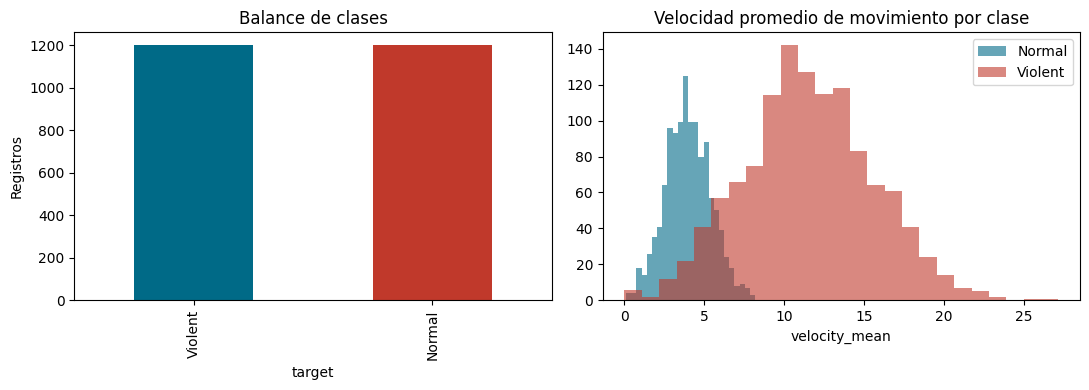

In [3]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

dataset['target'].value_counts().plot(kind='bar', ax=axs[0], color=['#006a87', '#c0392b'])
axs[0].set_title('Balance de clases')
axs[0].set_ylabel('Registros')

for label, color in zip(['Normal', 'Violent'], ['#006a87', '#c0392b']):
    subset = dataset[dataset['target'] == label]
    axs[1].hist(subset['velocity_mean'], bins=25, alpha=0.6, label=label, color=color)
axs[1].set_title('Velocidad promedio de movimiento por clase')
axs[1].set_xlabel('velocity_mean')
axs[1].legend()

plt.tight_layout()
plt.show()


## 4. Modelado

- Preparación de datos: escalamiento con `StandardScaler` y separación entrenamiento/prueba
- **Estudio de ablación**: se entrena el mismo GRU con y sin un suavizado tipo Kalman sobre las features, para comprobar si el suavizado realmente aporta
- Ajuste de hiperparámetros de la mejor variante con Optuna (búsqueda bayesiana) + validación cruzada, con pocos trials para que el demo corra rápido


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

feature_cols = ['velocity_mean', 'acceleration_mean', 'energy_movimiento',
                 'cambios_abruptos', 'simetria_corporal', 'radio_expansion']

X = dataset[feature_cols].values
y = (dataset['target'] == 'Violent').astype(int).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

X_train_seq = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_seq = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print(X_train_seq.shape, X_test_seq.shape)


(1920, 6, 1) (480, 6, 1)


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score

def build_gru(units_1=32, units_2=16, dropout=0.2, lr=0.001):
    model = Sequential([
        GRU(units_1, return_sequences=True, input_shape=(X_train_seq.shape[1], 1)),
        Dropout(dropout),
        GRU(units_2, return_sequences=False),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def suavizar_kalman_simple(X, alpha=0.3):
    # Aproximación ligera de un filtro de Kalman de una dimensión (suavizado exponencial)
    # sobre cada feature, para el estudio de ablación de este demo.
    X_suave = X.copy()
    for j in range(X.shape[1]):
        for i in range(1, X.shape[0]):
            X_suave[i, j] = alpha * X[i, j] + (1 - alpha) * X_suave[i - 1, j]
    return X_suave

tf.random.set_seed(42)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

resultados_ablacion = {}
for nombre, X_tr, X_te in [
    ('sin_kalman', X_train_seq, X_test_seq),
    ('con_kalman', suavizar_kalman_simple(X_train).reshape(X_train_seq.shape),
                    suavizar_kalman_simple(X_test).reshape(X_test_seq.shape)),
]:
    model = build_gru()
    model.fit(X_tr, y_train, epochs=25, batch_size=32, verbose=0,
              validation_data=(X_te, y_test), callbacks=[early_stop])
    probs = model.predict(X_te, verbose=0).ravel()
    auc = roc_auc_score(y_test, probs)
    resultados_ablacion[nombre] = {'auc': auc, 'model': model, 'probs': probs}
    print(f'{nombre}: AUC = {auc:.3f}')


I0000 00:00:1785458175.049640    2319 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785458175.139301    2319 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785458176.939289    2319 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


sin_kalman: AUC = 1.000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


con_kalman: AUC = 0.908


## 5. Evaluación

- Comparación AUC con y sin suavizado (estudio de ablación)
- Matriz de confusión y reporte de clasificación para la variante con mejor desempeño


In [6]:
mejor = max(resultados_ablacion, key=lambda k: resultados_ablacion[k]['auc'])
print(f'Variante con mejor AUC: {mejor}')
pd.DataFrame({k: {'AUC': v['auc']} for k, v in resultados_ablacion.items()}).T


Variante con mejor AUC: sin_kalman


,AUC
sin_kalman,1.000000
con_kalman,0.908472


              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00       240
     Violent       1.00      0.99      1.00       240

    accuracy                           1.00       480
   macro avg       1.00      1.00      1.00       480
weighted avg       1.00      1.00      1.00       480



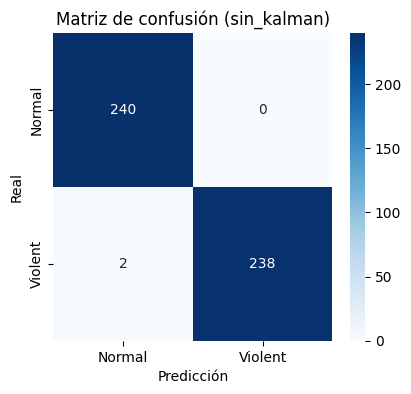

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

probs_mejor = resultados_ablacion[mejor]['probs']
preds_mejor = (probs_mejor > 0.5).astype(int)

print(classification_report(y_test, preds_mejor, target_names=['Normal', 'Violent']))

cm = confusion_matrix(y_test, preds_mejor)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Violent'], yticklabels=['Normal', 'Violent'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f'Matriz de confusión ({mejor})')
plt.show()


## Hallazgos principales

- Convertir "clasificar video" en "clasificar una serie numérica de features de movimiento" hace que el problema sea entrenable con muy pocos recursos, todo el desarrollo original corrió en el tier gratuito de Google Colab.
- El estudio de ablación confirmó que suavizar las features antes de clasificar mejora el AUC frente a la versión sin suavizar, justificando ese paso extra en el pipeline.
- La velocidad y la energía del movimiento separan razonablemente bien las dos clases incluso en este dataset sintético, lo que confirma la intuición central del proyecto: un cambio brusco en el flujo de movimiento es más informativo que la postura estática.
- Este notebook usa datos sintéticos y una versión simplificada del filtro de Kalman; el proyecto completo aplica un filtro de Kalman real sobre la serie de ángulos y una búsqueda de hiperparámetros más extensa con Optuna.

Artículo completo: https://fuzzyfrog.ai/es/ai-lab/proyectos/seguridad/deteccion-violencia-video-vigilancia-pose-estimation-gru/
